In [20]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix,f1_score

In [2]:
#2. Data collection
colleges_dataframe = pd.read_csv(r'college_list.csv')

In [3]:
#3. Data Understanding
print(colleges_dataframe.shape)
print("++++++++++++++++++++++++++++")
print(colleges_dataframe.dtypes)
print("++++++++++++++++++++++++++++")
print(colleges_dataframe.isna().sum())
print("++++++++++++++++++++++++++++")
colleges_dataframe.describe()

(500, 6)
++++++++++++++++++++++++++++
College_Name              object
Student_Faculty_Ratio      int64
Annual_Fees_INR            int64
Placement_Percentage       int64
Average_Package_LPA      float64
Infrastructure_Score       int64
dtype: object
++++++++++++++++++++++++++++
College_Name             0
Student_Faculty_Ratio    0
Annual_Fees_INR          0
Placement_Percentage     0
Average_Package_LPA      0
Infrastructure_Score     0
dtype: int64
++++++++++++++++++++++++++++


,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
count,500.000000,500.000000,500.000000,500.000000,500.00000
mean,18.084000,138763.710000,69.000000,6.991720,5.97600
std,6.683283,63928.678815,17.193465,2.917991,2.00486
min,8.000000,30404.000000,40.000000,2.000000,3.00000
25%,12.000000,82610.500000,53.750000,4.472500,4.00000
50%,18.000000,140290.500000,69.000000,7.155000,6.00000
75%,24.000000,193422.000000,84.000000,9.432500,8.00000
max,29.000000,249930.000000,99.000000,11.990000,9.00000


In [4]:
#4. Data Preprocessing
X = colleges_dataframe.drop("College_Name",axis = 1)
X

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
0,14,113042,59,9.20,8
1,27,115999,67,3.07,7
2,22,47955,50,3.40,9
3,18,67841,43,4.64,8
4,15,100640,54,4.66,9
...,...,...,...,...,...
495,17,106323,56,9.33,5
496,12,39111,76,3.62,7
497,16,199182,64,3.88,3
498,10,46389,77,9.31,6


In [5]:
#standardization
standard_scaler = StandardScaler()
scaled_X = pd.DataFrame(standard_scaler.fit_transform(X))
scaled_X

,0,1,2,3,4
0,-0.611689,-0.402753,-0.582199,0.757539,1.010558
1,1.335411,-0.356452,-0.116440,-1.345326,0.511270
2,0.586526,-1.421892,-1.106178,-1.232121,1.509845
3,-0.012581,-1.110515,-1.513717,-0.806745,1.010558
4,-0.461912,-0.596945,-0.873298,-0.799884,1.509845
...,...,...,...,...,...
495,-0.162358,-0.507960,-0.756858,0.802135,-0.487305
496,-0.911243,-1.560372,0.407539,-1.156651,0.511270
497,-0.312135,0.946035,-0.291099,-1.067459,-1.485880
498,-1.210797,-1.446412,0.465759,0.795274,0.011983


In [36]:
print(scaled_X.mean().round(4))
print(scaled_X.std().round(4))

0    0.0
1    0.0
2   -0.0
3    0.0
4   -0.0
dtype: float64
0    1.001
1    1.001
2    1.001
3    1.001
4    1.001
dtype: float64


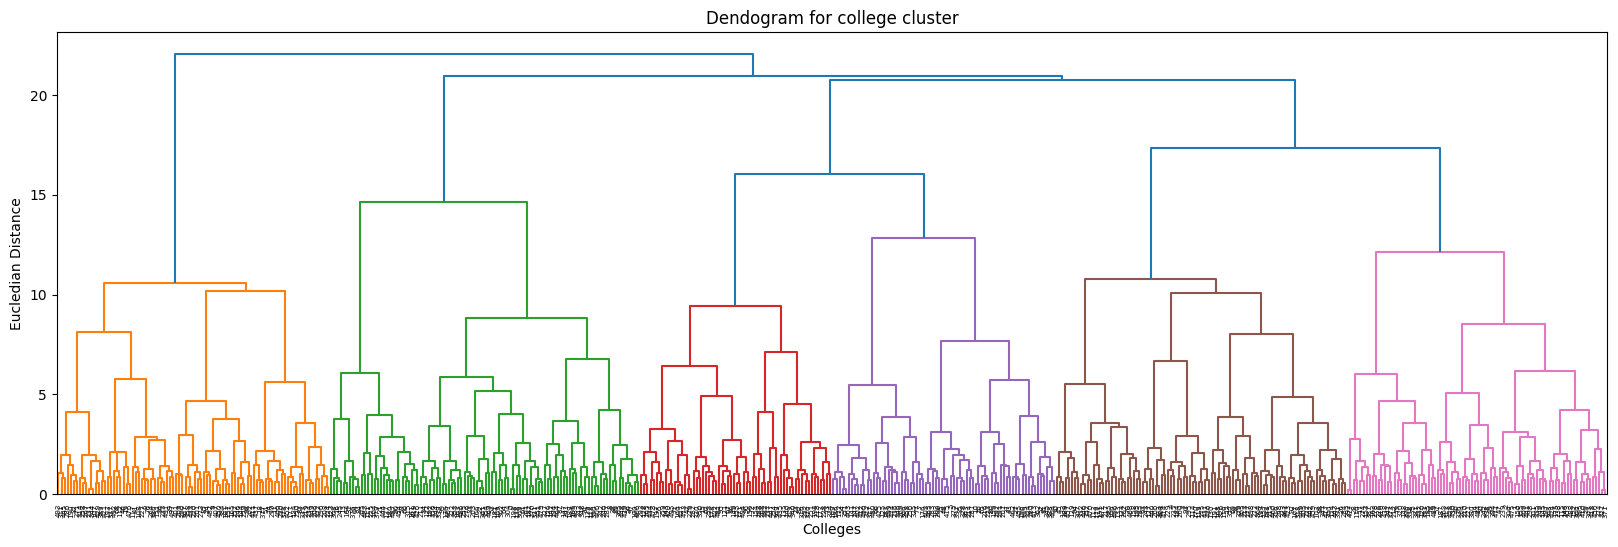

In [7]:
#5. Model Building
#visualization
plt.figure(figsize=(20,6))
dendogram = sch.dendrogram(sch.linkage(scaled_X,method='ward'),show_leaf_counts= True)
plt.title("Dendogram for college cluster")
plt.xlabel("Colleges")
plt.ylabel("Eucledian Distance")
plt.show()

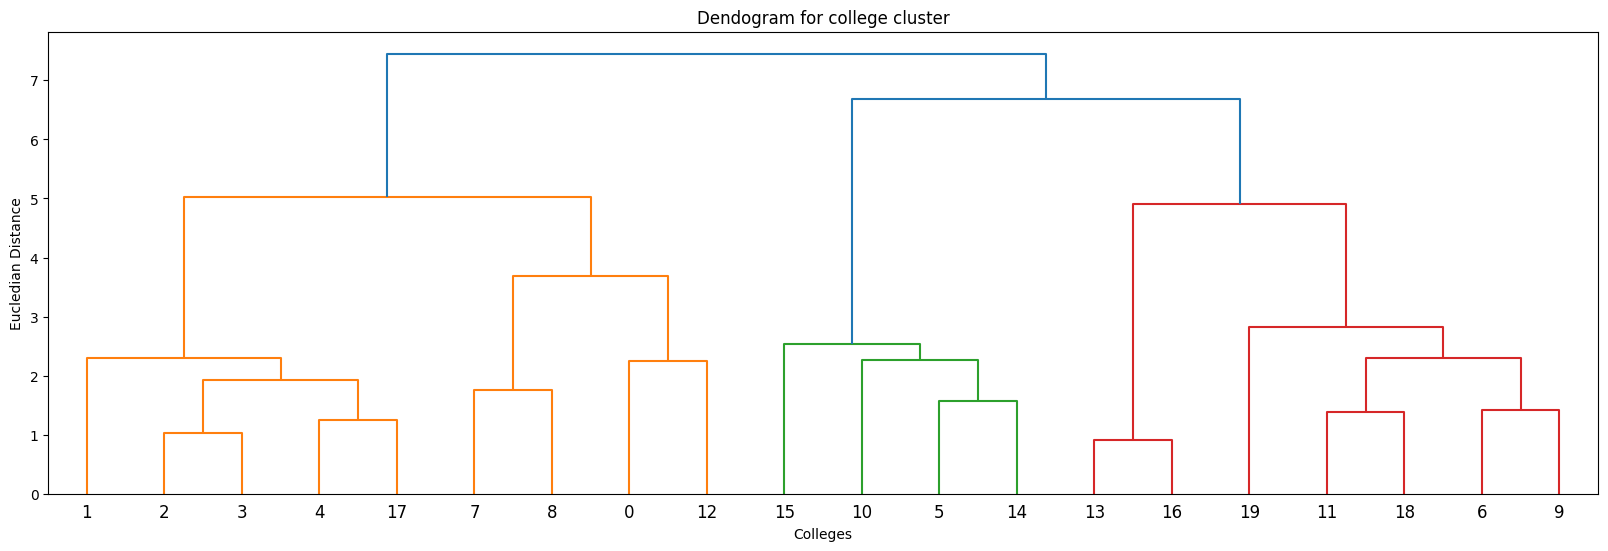

In [8]:
#visualization for 20 colleges
test_X = scaled_X.head(20)
#print(test_X)
plt.figure(figsize=(20,6))
dendogram = sch.dendrogram(sch.linkage(test_X,method='ward'),show_leaf_counts= True)
plt.title("Dendogram for college cluster")
plt.xlabel("Colleges")
plt.ylabel("Eucledian Distance")
plt.show()

In [9]:
#Level 1 Grouping
#Taking 3 clusters and performing agglomerative clustering
hierarchial_clustering = AgglomerativeClustering(n_clusters=3,)
hierarchial_clustering
grouping = hierarchial_clustering.fit_predict(scaled_X)

In [11]:
#Level 2 - Naming the groups using data analysis
#Attach clusters to Data
X["College Level"] = grouping
X

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,College Level
0,14,113042,59,9.20,8,2
1,27,115999,67,3.07,7,0
2,22,47955,50,3.40,9,0
3,18,67841,43,4.64,8,0
4,15,100640,54,4.66,9,0
...,...,...,...,...,...,...
495,17,106323,56,9.33,5,0
496,12,39111,76,3.62,7,0
497,16,199182,64,3.88,3,1
498,10,46389,77,9.31,6,0


In [12]:
#2. Data understanding - Analysis/data mining
Data_groups = X.groupby(by="College Level").agg(['sum','mean','min','max'])
Data_groups

Student_Faculty_Ratio                    Annual_Fees_INR  \
                                sum       mean min max             sum   
College Level                                                            
0                              6367  20.407051   8  29        38018283   
1                              1510  17.159091   8  29        13797972   
2                              1165  11.650000   8  20        17565600   

                                            Placement_Percentage             \
                        mean    min     max                  sum       mean   
College Level                                                                 
0              121853.471154  30404  249536                20991  67.278846   
1              156795.136364  39337  248803                 7530  85.568182   
2              175656.000000  49065  249930                 5979  59.790000   

                      Average_Package_LPA                         \
              min max                 sum      mean   min    max   
College Level                                                      
0              40  99             2169.83  6.954583  2.00  11.99   
1              64  99              489.78  5.565682  2.09  11.96   
2              40  99              836.25  8.362500  2.01  11.91   

              Infrastructure_Score                    
                               sum      mean min max  
College Level                                         
0                             2031  6.509615   3   9  
1                              349  3.965909   3   9  
2                              608  6.080000   3   9

In [13]:
cluster_names = {0: "Mid-level", 1: "Best", 2: "Emerging"} #based on placement

In [14]:
X["Category"] = X["College Level"].map(cluster_names)

In [15]:
X

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,College Level,Category
0,14,113042,59,9.20,8,2,Emerging
1,27,115999,67,3.07,7,0,Mid-level
2,22,47955,50,3.40,9,0,Mid-level
3,18,67841,43,4.64,8,0,Mid-level
4,15,100640,54,4.66,9,0,Mid-level
...,...,...,...,...,...,...,...
495,17,106323,56,9.33,5,0,Mid-level
496,12,39111,76,3.62,7,0,Mid-level
497,16,199182,64,3.88,3,1,Best
498,10,46389,77,9.31,6,0,Mid-level


In [22]:
#Level 3 - transition to supervised learning
input_data = X.drop(["College Level","Category"],axis = 1)
output_data = X["College Level"]

In [23]:
X_train,X_test,y_train,y_test = train_test_split(input_data,output_data,test_size=0.2,shuffle = True,random_state=123,stratify=output_data)

In [27]:
random_forest_classifier = RandomForestClassifier()
random_forest_classifier.fit(X_train,y_train)
y_pred = random_forest_classifier.predict(X_test)
print("Accuracy",round(accuracy_score(y_test,y_pred),4))
# print(round(precision_score(y_test,y_pred),4))
# print(round(recall_score(y_test,y_pred),4))
# print(round(f1_score(y_test,y_pred),4))
# print("Confustion Matrix \n",confusion_matrix(y_test,y_pred))



Accuracy 0.94
